# 3. Host-guest networks

Podcasts share guests. A person appears on one show, then another, and the shows
they connect form a network — the "podcast circuit". Mapping it tells you which
shows sit at the centre of a scene, and which communities of shows draw on the
same people.

SPoRC gives every episode a `host_predicted_names` and a `guest_predicted_names`.
So the network looks like three lines of code.

**Those three lines produce a wrong answer.** This notebook builds the naive
version, shows how to catch that it's wrong, and then builds the real one.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../.."))     # prefer the source tree
sys.path.insert(0, os.path.dirname(os.path.abspath("_viz.py")))

import sporc
if sporc.__version__ < "1.0":
    raise RuntimeError(
        f"This notebook needs sporc >= 1.0 but imported {sporc.__version__} from "
        f"{os.path.dirname(sporc.__file__)}.\n"
        "PyPI's latest release is 0.2.0, which has a different API, so "
        "`pip install sporc` gets you the wrong one. Install this checkout:\n"
        "    pip install -e /path/to/sporc"
    )

from _viz import apply_style, finish, PALETTE, INK, INK_SECONDARY, INK_MUTED
apply_style()
print("sporc", sporc.__version__, "from", os.path.dirname(sporc.__file__))


sporc 1.0.0 from /home/jurgens/projects/sporc/sporc


In [2]:
from sporc import SPORCDataset

# Built by scripts/make_subset.py; see examples/notebooks/README.md.
SUBSET = os.path.abspath("../../subsets/tutorial")
sporc = SPORCDataset(parquet_dir=SUBSET)
print(sporc)


INFO:sporc.dataset:Initializing Parquet backend from /home/jurgens/projects/sporc/subsets/tutorial


INFO:sporc.parquet_backend:Loading indexes from cache /home/jurgens/projects/sporc/subsets/tutorial/metadata/_index_cache.pkl


INFO:sporc.parquet_backend:ParquetBackend loaded from cache in 0.11s  (512 podcasts, 2,428 episodes)


SPORCDataset(parquet, 512 podcasts, 2428 episodes)


## 3.1 A network from guest_predicted_names

Take every episode, connect its hosts to its guests. Done.


In [3]:
from collections import Counter
import itertools

eps = list(sporc.iterate_episodes())

guest_pods = Counter()          # guest -> number of DISTINCT podcasts
guest_rows = []
for e in eps:
    for g in (e.guest_names or []):
        guest_rows.append((g.strip().lower(), e.podcast_title, e.title))

pods_per_guest = {}
for g, pod, _ in guest_rows:
    pods_per_guest.setdefault(g, set()).add(pod)

top = sorted(pods_per_guest.items(), key=lambda kv: -len(kv[1]))[:12]
print("Most-connected 'guests' by number of distinct podcasts:\n")
for name, pods in top:
    print(f"  {len(pods):3d} podcasts   {name}")


INFO:sporc.parquet_backend:Loading episode DataFrame from feather cache


INFO:sporc.parquet_backend:Loading podcast DataFrame from feather cache


Most-connected 'guests' by number of distinct podcasts:

   13 podcasts   brian green
    7 podcasts   benjamin hardy
    4 podcasts   dave rubin
    4 podcasts   kwame christian
    3 podcasts   david ditchfield
    3 podcasts   antonio garrito
    3 podcasts   maggie reyes
    3 podcasts   chris ronsio
    3 podcasts   richard haas
    3 podcasts   michael ray
    3 podcasts   chris smith
    3 podcasts   lisa marie


## 3.2 Reading the guest list

Depending on your subset you will likely see names like **George Floyd**,
**Breonna Taylor**, **Anthony Fauci**, **Joe Biden** — possibly **Jesus Christ**,
possibly **Kia ora** (a Māori greeting, not a person).

George Floyd was killed on 25 May 2020, in the middle of this corpus's window.
He was not a podcast guest on dozens of shows. He was *talked about* on dozens of
shows.

`guest_predicted_names` conflates **people mentioned** with **people present**.
It is a name-extraction field, and the extraction has no way to tell "we're
joined today by X" from "let's talk about what happened to X".

This is not a small error at the edges. In the full corpus George Floyd is listed
as a guest on **237 podcasts** — the single most "connected guest" in SPoRC.
A network built on this field is a **mention network** wearing a host–guest
label, and every centrality number computed from it is about who got discussed.

**How big is the problem?** We scanned all 14,124 podcasts that claim a
cross-podcast guest and checked each against `guest_speaker_labels`:

| name | claimed guest on | actually spoke on | |
|---|---|---|---|
| george floyd | 237 podcasts | 5 | ↓ 98% |
| anthony fauci | 73 | 1 | ↓ 99% |
| breonna taylor | 58 | **0** | ↓ 100% |
| joe biden | 37 | **0** | ↓ 100% |
| kia ora *(a greeting)* | 36 | **0** | ↓ 100% |
| | | | |
| benjamin hardy | 67 | **13** | ↓ 81% |
| dave rubin | 24 | **5** | ↓ 79% |
| matt ridley | 26 | **5** | ↓ 81% |

The pattern is the finding. News figures collapse to zero; people who genuinely
worked the podcast circuit in 2020 — an author on a book tour, a fellow
podcaster — keep a fifth of their claimed appearances.

Corpus-wide: **37,275 names look like cross-podcast guests. 940 survive
validation — 2.5%.**


## 3.3 Validating against guest_speaker_labels

Diarization assigns speaker labels (`SPEAKER_00`, ...). A separate step tries to
attach names to those labels. When a guest actually **speaks**, they get an entry
in `guest_speaker_labels`. When they are merely named, they don't.

Compare the two fields on a suspicious episode:


In [4]:
import json

def labels(e, attr):
    """guest/host_speaker_labels come through as a dict or a JSON string."""
    v = getattr(e, attr, None) or {}
    if isinstance(v, str):
        try:
            v = json.loads(v)
        except Exception:
            return {}
    return v if isinstance(v, dict) else {}

# An episode where a famous name is claimed as a guest.
FAMOUS = {"george floyd", "breonna taylor", "anthony fauci", "joe biden",
          "donald trump", "jesus christ"}
suspect = None
for e in eps:
    names = {g.strip().lower() for g in (e.guest_names or [])}
    if names & FAMOUS:
        suspect = e
        break

if suspect is None:
    print("No famous-name episode in this subset; showing any multi-guest episode.")
    suspect = next((e for e in eps if e.guest_names), eps[0])

print(f"episode  : {suspect.title[:60]!r}")
print(f"podcast  : {suspect.podcast_title[:60]!r}")
print()
print(f"  guest_predicted_names : {suspect.guest_names}")
print(f"  guest_speaker_labels  : {labels(suspect, 'guest_speaker_labels')}")
print(f"  host_speaker_labels   : {labels(suspect, 'host_speaker_labels')}")
print(f"  main_ep_speakers      : {suspect.main_ep_speakers}")
print(f"  num_main_speakers     : {suspect.num_main_speakers}")
print()
print("An empty guest_speaker_labels with one main speaker means a solo")
print("monologue: the 'guests' are people the host talked about.")


No famous-name episode in this subset; showing any multi-guest episode.
episode  : 'PMP#49: Conspiracy Theories as Pop w/ Al Baker'
podcast  : 'Pretty Much Pop: A Culture Podcast'

  guest_predicted_names : ['Erica Spires', 'Brian Rothschild', 'Brian Hurt', 'Al Baker']
  guest_speaker_labels  : {}
  host_speaker_labels   : {}
  main_ep_speakers      : ['SPEAKER_03', 'SPEAKER_04', 'SPEAKER_06', 'SPEAKER_08']
  num_main_speakers     : 4

An empty guest_speaker_labels with one main speaker means a solo
monologue: the 'guests' are people the host talked about.


## 3.4 How many claimed guests survive

How many claimed guest appearances survive the check that the guest actually got
a speaker label?


In [5]:
claimed = 0
real = 0
for e in eps:
    gl = {k.strip().lower() for k in labels(e, "guest_speaker_labels")}
    for g in (e.guest_names or []):
        claimed += 1
        if g.strip().lower() in gl:
            real += 1

print(f"claimed guest appearances        : {claimed:,}")
print(f"backed by a real speaker label   : {real:,}  ({real/max(claimed,1):.1%})")
print(f"mentions masquerading as guests  : {claimed-real:,}  "
      f"({1-real/max(claimed,1):.1%})")


claimed guest appearances        : 1,070
backed by a real speaker label   : 359  (33.6%)
mentions masquerading as guests  : 711  (66.4%)


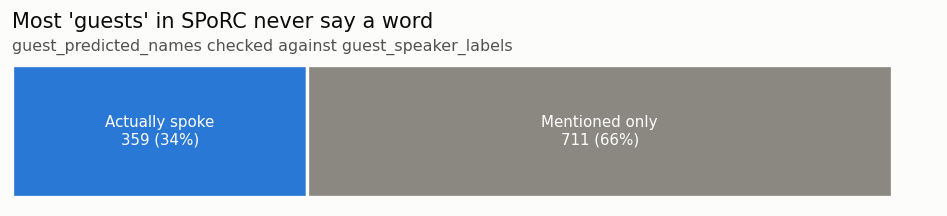

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 1.9))
vals = [real, claimed - real]
labs = ["Actually spoke", "Mentioned only"]
cols = [PALETTE[0], INK_MUTED]
left = 0
for v, l, c in zip(vals, labs, cols):
    ax.barh([0], [v], left=left, color=c, height=0.5,
            edgecolor="#fcfcfb", linewidth=2)
    if v / max(claimed, 1) > 0.04:
        ax.annotate(f"{l}\n{v:,} ({v/claimed:.0%})", (left + v/2, 0),
                    ha="center", va="center", fontsize=9,
                    color="white" if c == INK_MUTED else "white")
    left += v
ax.set_yticks([]); ax.set_xticks([]); ax.grid(False)
for s in ("left", "bottom"):
    ax.spines[s].set_visible(False)
finish(ax, title="Most 'guests' in SPoRC never say a word",
       subtitle="guest_predicted_names checked against guest_speaker_labels")
plt.show()


## 3.5 The validated network

Now connect podcasts through guests who **actually spoke**. Nodes are podcasts;
an edge means they share a validated guest.


In [7]:
import networkx as nx

# guest -> podcasts where they hold a real speaker label
real_guest_pods = {}
for e in eps:
    gl = {k.strip().lower() for k in labels(e, "guest_speaker_labels")}
    for g in gl:
        real_guest_pods.setdefault(g, set()).add(e.podcast_title)

shared = {g: p for g, p in real_guest_pods.items() if len(p) >= 2}
print(f"validated guests            : {len(real_guest_pods):,}")
print(f"...appearing on >=2 podcasts: {len(shared):,}")

G = nx.Graph()
for g, pods in shared.items():
    for a, b in itertools.combinations(sorted(pods), 2):
        if G.has_edge(a, b):
            G[a][b]["weight"] += 1
            G[a][b]["guests"].append(g)
        else:
            G.add_edge(a, b, weight=1, guests=[g])

print(f"\nnetwork: {G.number_of_nodes()} podcasts, {G.number_of_edges()} shared-guest links")
if G.number_of_nodes():
    comps = sorted(nx.connected_components(G), key=len, reverse=True)
    print(f"components: {len(comps)}, largest has {len(comps[0])} podcasts")


validated guests            : 277
...appearing on >=2 podcasts: 38

network: 96 podcasts, 156 shared-guest links
components: 33, largest has 13 podcasts


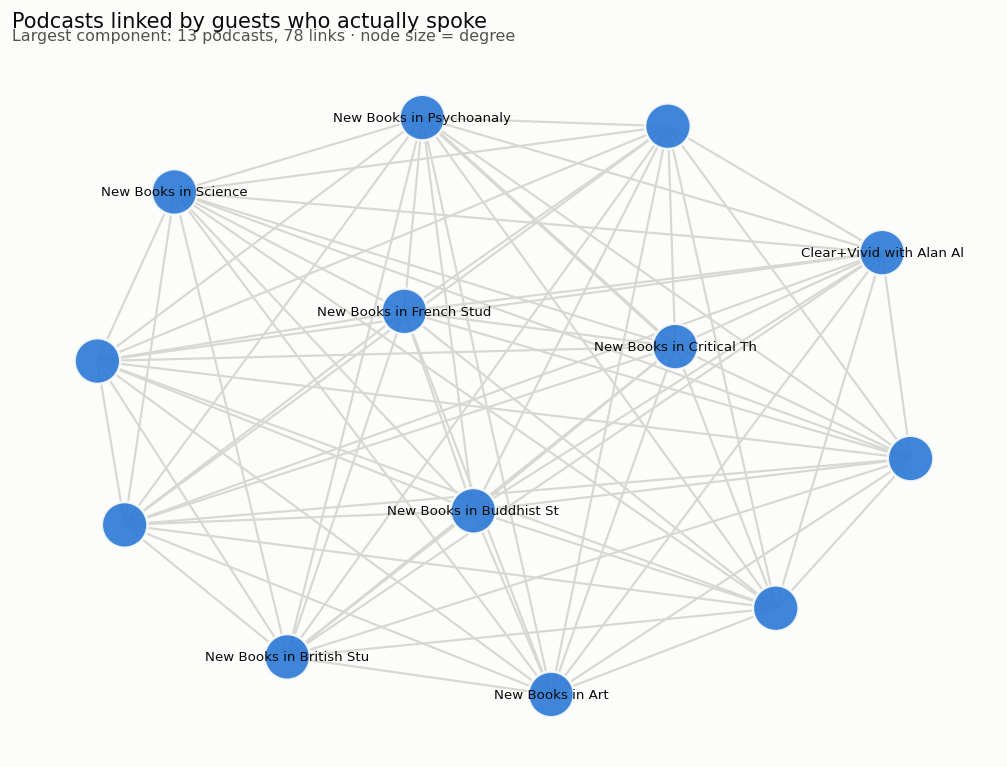

In [8]:
if G.number_of_edges():
    # Largest component only: isolated pairs carry no structure worth drawing.
    core = G.subgraph(max(nx.connected_components(G), key=len)).copy()
    pos = nx.spring_layout(core, seed=7, k=0.75, weight="weight")
    deg = dict(core.degree())

    fig, ax = plt.subplots(figsize=(8.5, 6.5))
    nx.draw_networkx_edges(core, pos, ax=ax, edge_color="#d8d7d2",
                           width=[0.6 + 0.7*core[u][v]["weight"] for u, v in core.edges()])
    nx.draw_networkx_nodes(core, pos, ax=ax,
                           node_size=[90 + 55*deg[n] for n in core.nodes()],
                           node_color=PALETTE[0], alpha=0.9,
                           edgecolors="#fcfcfb", linewidths=1.5)
    # Label only the hubs: labelling everything is unreadable.
    hubs = sorted(deg, key=deg.get, reverse=True)[:8]
    nx.draw_networkx_labels(core, pos, ax=ax,
                            labels={n: n[:24] for n in hubs},
                            font_size=8, font_color=INK)
    ax.axis("off")
    finish(ax, title="Podcasts linked by guests who actually spoke",
           subtitle=f"Largest component: {core.number_of_nodes()} podcasts, "
                    f"{core.number_of_edges()} links · node size = degree")
    plt.show()
else:
    print("No shared-guest edges in this subset.")
    print("Expected: random podcasts rarely share a guest. The tutorial subset")
    print("is selected to contain some; see examples/notebooks/README.md.")


## 3.6 Centrality

Degree counts links. Betweenness finds the shows that *bridge* otherwise separate
scenes — often more interesting, since a bridge show is where communities meet.


In [9]:
if G.number_of_edges():
    import pandas as pd
    btw = nx.betweenness_centrality(core, weight=None)
    cen = (pd.DataFrame({"podcast": list(core.nodes()),
                         "degree": [core.degree(n) for n in core.nodes()],
                         "betweenness": [btw[n] for n in core.nodes()]})
             .sort_values("betweenness", ascending=False).head(10))
    print(cen.round(3).to_string(index=False))


                           podcast  degree  betweenness
              New Books in Science      12          0.0
       New Books in French Studies      12          0.0
      New Books in Critical Theory      12          0.0
                  New Books in Art      12          0.0
     New Books in Buddhist Studies      12          0.0
        Clear+Vivid with Alan Alda      12          0.0
      New Books in British Studies      12          0.0
       New Books in Psychoanalysis      12          0.0
New Books in Physics and Chemistry      12          0.0
       New Books in German Studies      12          0.0


## 3.7 Caveats

**The finding.** `guest_predicted_names` answers "who was named in this episode",
not "who was on this episode". For a corpus published in May–June 2020, the most
"connected guest" is a man who was killed on 25 May and never appeared on a
podcast. Validate against `guest_speaker_labels` before treating a guest edge as
an appearance.

**The general habit.** The naive network was not obviously broken. It ran, it
produced a plausible graph, and it had sensible-looking hubs. It only fell apart
when we *read the top of the list and asked whether it could be true*. Sorting by
your headline metric and eyeballing the extremes catches more bugs than any test
suite here.

**Caveats on the corrected network too:**

* **The fix is a big improvement, not a cure.** Across the full corpus, checking
  `guest_speaker_labels` takes George Floyd from **237 podcasts down to 5** — a
  ~98% cut. Not to zero. The name-attribution step occasionally pins a *mentioned*
  name onto a real speaker, so a handful of impossible appearances survive. Sort
  your validated list and read the top of it; the residue is small enough to
  eyeball and too systematic to ignore.
* `guest_speaker_labels` is itself inferred. It confirms *someone* was diarized
  and named — not that the name is right.
* Only ~33% of episodes are diarized (notebook 01), so a real guest on an
  undiarized episode is invisible. The corrected network is a **lower bound**.
* Name strings are unnormalized: "Dr. Jane Smith" and "Jane Smith" are two
  people here. Serious work needs entity resolution.

Next: **04 · Language across repeat guest appearances**, which needs exactly the
validated guests built here.
